## Question 1: What is Simple Linear Regression?

It attempts to determine the strength and charachteristics of relationship between one independent variable(x) and another dependent variable (y).


---

## Question 2: What are the key assumptions of Simple Linear Regression?

The key assumptions are:

1. **Linearity**
   The relationship between the independent and dependent variables is linear.

2. **Independence of Errors**
   Residuals are independent of each other.

3. **Homoscedasticity**
   The variance of residuals is constant across all levels of the independent variable.

4. **Normality of Errors**
   Residuals are normally distributed.

5. **No Multicollinearity**
   (Automatically satisfied in simple linear regression since there is only one predictor.)

---

## Question 3: What is heteroscedasticity, and why is it important to address in regression models?

Heteroscedasticity occurs when the variance of the residuals is not constant across all values of the independent variable.
It often appears as a funnel-shaped pattern in residual plots.

**Why it matters:**

* Leads to inefficient and biased standard error estimates
* Makes hypothesis testing (t-tests, F-tests) unreliable
* Affects confidence intervals and p-values

Common solutions include data transformation, weighted least squares, or using robust standard errors.

---

## Question 4: What is Multiple Linear Regression?

Multiple Linear Regression is an extension of simple linear regression where one dependent variable is predicted using two or more independent variables.

The equation is:
[
Y = \beta_0 + \beta_1X_1 + \beta_2X_2 + \cdots + \beta_nX_n + \epsilon
]

It is used to:

* Analyze the effect of multiple predictors on a response variable
* Control for confounding variables
* Improve predictive accuracy

---

## Question 5: What is polynomial regression, and how does it differ from linear regression?

Polynomial Regression models the relationship between the independent variable and dependent variable as an nth-degree polynomial.

Example (degree 2):
[
Y = \beta_0 + \beta_1X + \beta_2X^2 + \epsilon
]

**Key differences from linear regression:**

* Captures non-linear relationships
* Still linear in parameters, but non-linear in features
* More flexible but prone to overfitting if degree is too high

Polynomial regression is useful when data shows curvature that a straight line cannot adequately model.



slope 1.98
intercept 0.18


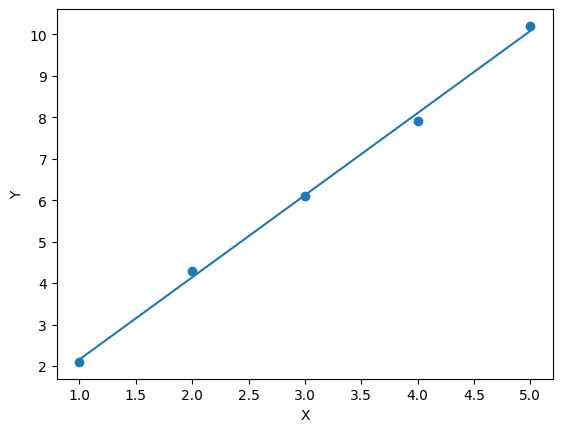

In [2]:
# Question 6: Implement a Python program to fit a Simple Linear Regression model to the following sample data:
# ● X = [1, 2, 3, 4, 5]
# ● Y = [2.1, 4.3, 6.1, 7.9, 10.2]
# Plot the regression line over the data points


import numpy as np
import matplotlib.pyplot as plt

X = np.array([1, 2, 3, 4, 5])
Y = np.array([2.1, 4.3, 6.1, 7.9, 10.2])

slope, intercept = np.polyfit(X,Y,1)

Y_pred = slope*X + intercept


print("slope", slope)
print("intercept", intercept)


plt.scatter(X,Y)
plt.plot(X, Y_pred)
plt.xlabel('X')
plt.ylabel("Y")
plt.show()





In [4]:
#Question 7: Fit a Multiple Linear Regression model on this sample data:
#● Area = [1200, 1500, 1800, 2000]
#● Rooms = [2, 3, 3, 4]
#● Price = [250000, 300000, 320000, 370000]
#Check for multicollinearity using VIF and report the results.

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = np.array([[1200,2],[1500,3],[1800,3],[2000,4]])
Y = np.array([250000, 300000, 320000, 370000])

model = LinearRegression()

model.fit(X,Y)

Y_pred = model.predict(X)

print("Slope", model.coef_)
print("Intercept", model.intercept_)

df = pd.DataFrame(X, columns = ['Area', 'Room'])
X_vif = sm.add_constant(df)

vif = pd.DataFrame()
vif["Feature"] = X_vif.columns

vif["VIF"] = [variance_inflation_factor(X_vif.values, i)
for i in range(X_vif.shape[1])]

print("\nVIF Results:")
print(vif)




Slope [   63.15789474 34736.84210526]
Intercept 103157.89473684214

VIF Results:
  Feature        VIF
0   const  34.210526
1    Area   7.736842
2    Room   7.736842


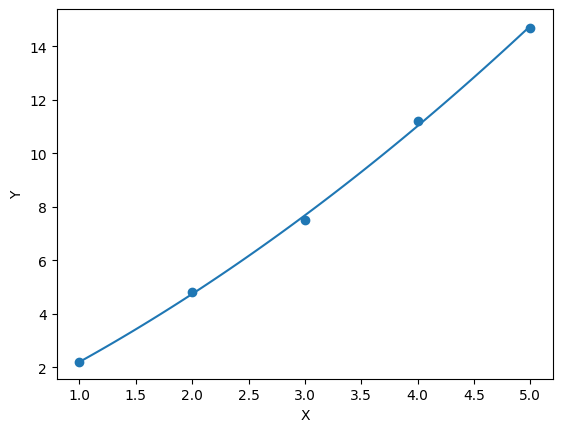

In [15]:
#Question 8: Implement polynomial regression on the following data:
#● X = [1, 2, 3, 4, 5]
#● Y = [2.2, 4.8, 7.5, 11.2, 14.7]
#Fit a 2nd-degree polynomial and plot the resulting curve.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

X = np.array([1, 2, 3, 4, 5])
Y = np.array([2.2, 4.8, 7.5, 11.2, 14.7])

coefficients = np.polyfit(X,Y,2)

poly_model = np.poly1d(coefficients)

# for smooth curve

X_curve = np.linspace(min(X), max(X), 100)
Y_curve = poly_model(X_curve)


plt.scatter(X,Y)
plt.plot(X_curve, Y_curve)

plt.xlabel("X")
plt.ylabel("Y")
plt.show()

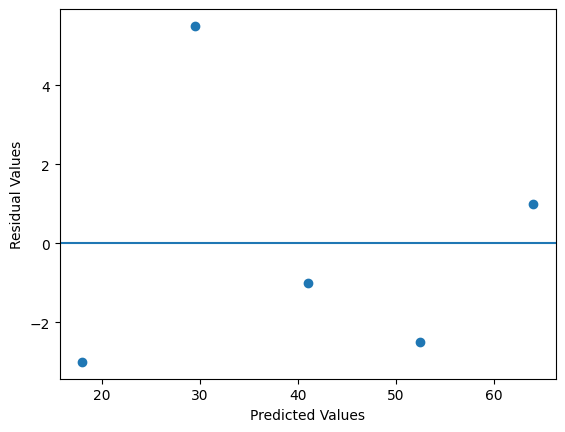

In [19]:
#Question 9: Create a residuals plot for a regression model trained on this data:
#● X = [10, 20, 30, 40, 50]
#● Y = [15, 35, 40, 50, 65]
#Assess heteroscedasticity by examining the spread of residuals.

X = np.array([10, 20, 30, 40, 50]).reshape(-1,1)
Y = np.array([15, 35, 40, 50, 65])

model = LinearRegression()

model.fit(X,Y)


Y_pred = model.predict(X)

residual = Y - Y_pred

plt.scatter(Y_pred, residual)
plt.axhline(y = 0)
plt.xlabel("Predicted Values")
plt.ylabel("Residual Values")
plt.show()





###Question 10: Imagine you are a data scientist working for a real estate company. You need to predict house prices using features like area, number of rooms, and location. However, you detect heteroscedasticity and multicollinearity in your regression model. Explain the steps you would take to address these issues and ensure a robust model.




## 1️⃣ Addressing Heteroscedasticity

### What is the Issue?

Heteroscedasticity occurs when the **variance of residuals is not constant** across levels of predicted values.
This leads to:

* Biased standard errors
* Invalid hypothesis tests
* Unreliable confidence intervals

---

### Steps to Handle Heteroscedasticity

#### Step 1: Detect the Problem

* Plot **residuals vs predicted values**
* Perform statistical tests:

  * Breusch–Pagan test
  * White’s test

---

#### Step 2: Apply Transformations

* Apply **log transformation** or **Box-Cox transformation** to the target variable (Price)

Example:
[
\log(\text{Price})
]

This stabilizes variance and improves linearity.

---

#### Step 3: Use Robust Standard Errors

* Apply **heteroscedasticity-robust (HC) standard errors**
* Ensures valid inference even if heteroscedasticity persists

---

#### Step 4: Consider Alternative Models

* **Weighted Least Squares (WLS)** if variance structure is known
* Tree-based models (Random Forest, Gradient Boosting) if linearity is weak

---

## 2️⃣ Addressing Multicollinearity

### What is the Issue?

Multicollinearity occurs when **independent variables are highly correlated**.

Consequences:

* Unstable coefficient estimates
* Inflated standard errors
* Difficult interpretation of feature importance

---

### Steps to Handle Multicollinearity

#### Step 1: Detect Multicollinearity

* Correlation matrix (heatmap)
* Variance Inflation Factor (VIF)

Guideline:

* VIF > 5 → moderate multicollinearity
* VIF > 10 → severe multicollinearity

---

#### Step 2: Feature Selection

* Remove redundant variables
  Example:

  * Area vs Built-up Area
* Keep the feature with higher business relevance

---

#### Step 3: Combine Features

* Create composite features
  Example:
  [
  \text{Price per Sqft} = \frac{\text{Price}}{\text{Area}}
  ]

---

#### Step 4: Apply Regularization

* **Ridge Regression** → Shrinks coefficients
* **Lasso Regression** → Performs feature selection

These techniques reduce coefficient variance and improve model stability.

---

## 3️⃣ Model Validation and Robustness Checks

To ensure a reliable final model:

* Use **cross-validation**
* Check:

  * Residual normality
  * Autocorrelation (if time-based data)
  * Prediction error metrics (RMSE, MAE)
* Compare linear vs regularized vs non-linear models

---

## 4️⃣ Final Business-Ready Approach

### Final Steps:

1. Diagnose issues using plots and statistical tests
2. Apply transformations and regularization
3. Re-evaluate assumptions
4. Validate with unseen data
5. Select the model that balances:

   * Accuracy
   * Interpretability
   * Business usefulness



